# Load Data

In [26]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\maxan\OneDrive\Desktop\0. Personal Projects\market-intelligence-pipeline")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [27]:
import pandas as pd
import numpy as np
import duckdb

from src.config import (
    DATABASE_PATH,
    ROLLING_WINDOWS,
    LAGGED_WINDOWS,
    MA_WINDOWS,
    TICKERS,
    START_DATE,
    END_DATE
)

from src.features import (
    build_price_feature_columns
)

CALENDAR = "no_calendar"


def pull_calendar_table(table_name: str, calendar: str) -> pd.DataFrame:

    print("[START] Connecting to database...")

    con = duckdb.connect(DATABASE_PATH)

    print(f"[START] Reading {table_name}")

    df = con.sql(f"""
    
        SELECT *
        FROM {table_name}

    """).df()

    print(f"[DONE] Read {table_name}")

    con.close()

    print(f"[START] Building {CALENDAR} required columns...")

    base_cols = [
        "ticker",
        "date",
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume"
    ]

    feature_columns = build_price_feature_columns(
        calendars = [CALENDAR],
        rolling_windows = ROLLING_WINDOWS,
        lagged_windows = LAGGED_WINDOWS,
        ma_windows = MA_WINDOWS
    )

    expected_columns = base_cols + list(feature_columns.keys())

    calendar_df = df[expected_columns].copy()

    print(f"[DONE] Filtered to {CALENDAR}")

    calendar_df["date"] = pd.to_datetime(calendar_df["date"])

    calendar_df = calendar_df.sort_values(["ticker", "date"])

    print(f"[DONE] Prepared and sorted table")

    return calendar_df

In [28]:
df = pull_calendar_table(
    table_name = "price_features", 
    calendar = CALENDAR
    )

print(f"[STEP] Loaded price_features table selecting {CALENDAR} columns")
print(df.head(10))
print(df.columns)

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar
[DONE] Prepared and sorted table
[STEP] Loaded price_features table selecting no_calendar columns
      ticker       date        open        high         low       close  \
0        GLD 2018-01-02  124.660004  125.180000  124.389999  125.150002   
1        GLD 2018-01-03  125.050003  125.089996  124.099998  124.820000   
8585     GLD 2018-01-04  124.889999  125.849998  124.739998  125.459999   
4299     GLD 2018-01-05  124.930000  125.480003  124.830002  125.330002   
2        GLD 2018-01-08  125.199997  125.320000  124.900002  125.309998   
7160     GLD 2018-01-09  124.489998  124.860001  124.230003  124.730003   
4300     GLD 2018-01-10  125.169998  125.309998  124.720001  125.029999   
10109    GLD 2018-01-11  125.370003  125.660004  125.250000  125.440002   
10110    GLD 2018-01-12  126.010002  127.129997  125.80

In [29]:
table_count = 0
graph_count = 0

# Rolling Volatility by Ticker

Graph 1:


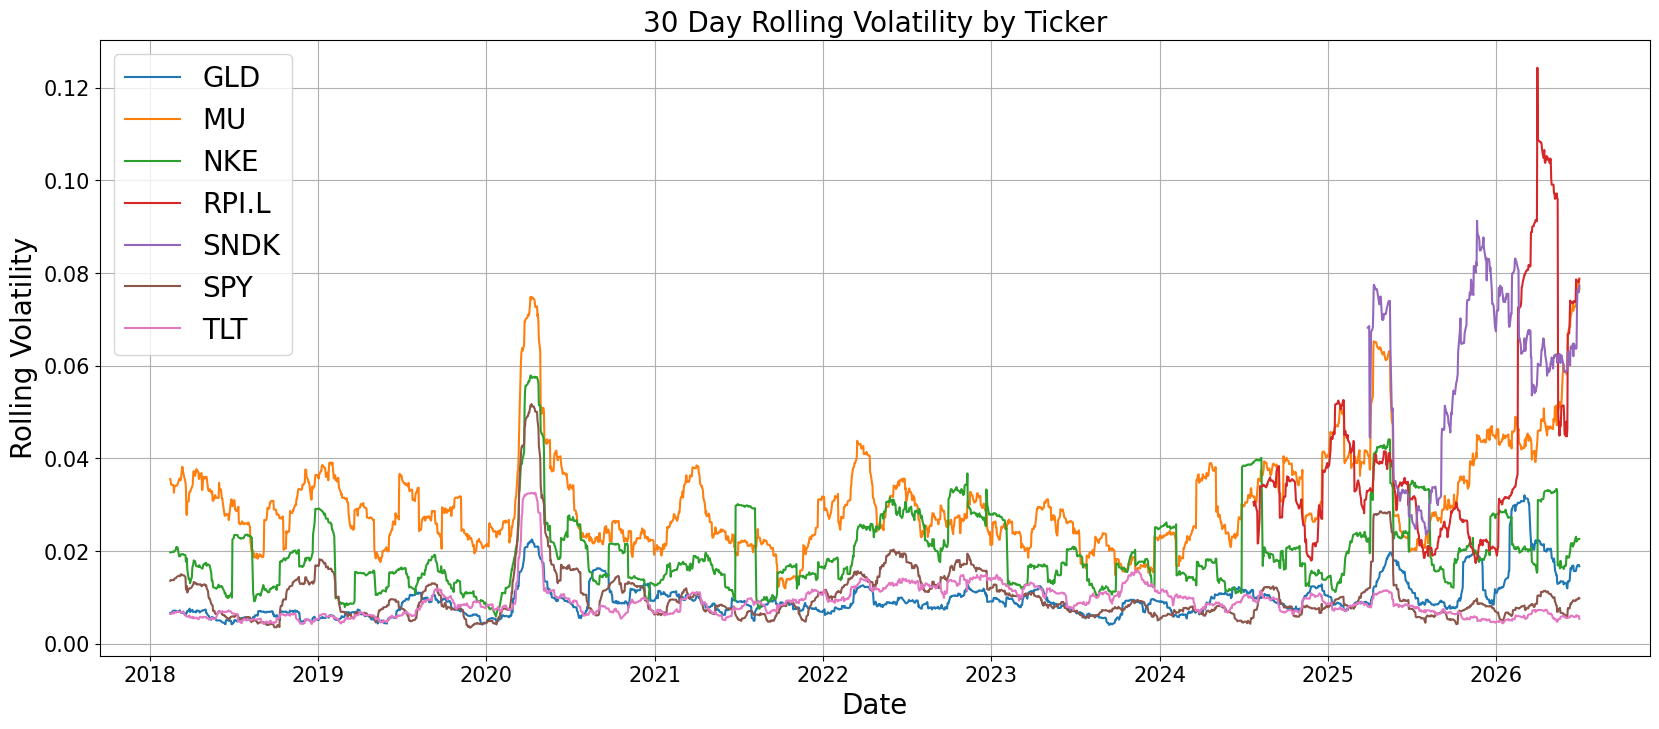

In [30]:
import matplotlib.pyplot as plt

df_1 = df.copy()

ticker = "ticker"
date="date"
rolling_volatility = f"rolling_30d_volatility_{CALENDAR}"

plt.figure(figsize=(20,8))

for asset, group in df_1.groupby(ticker):

    plt.plot(group[date], group[rolling_volatility], label = asset)

plt.legend(fontsize=20)
plt.title("30 Day Rolling Volatility by Ticker", fontsize=20)
plt.xlabel("Date", fontsize = 20)
plt.xticks(fontsize=15)
plt.ylabel("Rolling Volatility", fontsize=20)
plt.yticks(fontsize=15)
plt.grid()

graph_count += 1
print(f"Graph {graph_count}:")
plt.show()



# Max Drawdown by Ticker

In [31]:
import pandas as pd
import numpy as np
from IPython.display import display, display_html

# Your existing columns / variables
drawdown = f"drawdown_{CALENDAR}"

dd_df_2 = df.copy()

dd_df_2[date] = pd.to_datetime(dd_df_2[date])
dd_df_2 = dd_df_2.sort_values([ticker, date])

def make_drawdown_episodes(data, ticker_col, date_col, drawdown_col, tol=1e-6):
    rows = []

    for tkr, g in data.groupby(ticker_col):
        g = g.sort_values(date_col).reset_index(drop=True)

        underwater = g[drawdown_col] < -tol
        i = 0
        episode_no = 0
        last_date = g[date_col].max()

        while i < len(g):

            # Skip rows where asset is not in drawdown
            if not underwater.iloc[i]:
                i += 1
                continue

            # New drawdown episode starts
            episode_no += 1
            start_i = i

            # The peak is usually the row immediately before drawdown starts
            if start_i > 0:
                peak_date = g.loc[start_i - 1, date_col]
            else:
                peak_date = pd.NaT

            # Move forward until drawdown ends
            while i < len(g) and underwater.iloc[i]:
                i += 1

            end_i = i - 1

            # Drawdown segment
            segment = g.iloc[start_i:end_i + 1]

            # Trough = worst drawdown inside the episode
            trough_i = segment[drawdown_col].idxmin()
            trough_date = g.loc[trough_i, date_col]
            max_drawdown = g.loc[trough_i, drawdown_col]

            # Recovery = first row after episode where drawdown is back near zero
            if i < len(g):
                recovery_date = g.loc[i, date_col]
                recovery_days = (recovery_date - trough_date).days
                days_open = pd.NA
                recovered = True
            else:
                recovery_date = pd.NaT
                recovery_days = pd.NA
                days_open = (last_date - trough_date).days
                recovered = False

            rows.append({
                ticker_col: tkr,
                "episode": episode_no,
                "peak_date": peak_date,
                "trough_date": trough_date,
                "max_drawdown": max_drawdown,
                "recovery_date": recovery_date,
                "recovery_days": recovery_days,
                "days_open_if_unrecovered": days_open,
                "recovered": recovered
            })

    return pd.DataFrame(rows)

drawdown_episodes = make_drawdown_episodes(
    data=dd_df_2,
    ticker_col=ticker,
    date_col=date,
    drawdown_col=drawdown
)

drawdown_episodes["trough_year"] = drawdown_episodes["trough_date"].dt.year

drawdown_episodes["recovery_days"] = pd.to_numeric(
    drawdown_episodes["recovery_days"],
    errors="coerce"
)

drawdown_episodes["days_open_if_unrecovered"] = pd.to_numeric(
    drawdown_episodes["days_open_if_unrecovered"],
    errors="coerce"
)

episodes_display = drawdown_episodes.copy()

episodes_display["max_drawdown"] = episodes_display["max_drawdown"].map("{:.2%}".format)

recovery_stats = (
    drawdown_episodes
        .groupby(ticker)
        .agg(
            drawdown_events=("episode", "count"),
            recovered_events=("recovered", "sum"),
            worst_drawdown=("max_drawdown", "min"),
            average_drawdown=("max_drawdown", "mean"),
            median_recovery_days=("recovery_days", "median"),
            average_recovery_days=("recovery_days", "mean"),
            max_recovery_days=("recovery_days", "max"),
            current_open_drawdown_days=("days_open_if_unrecovered", "max")
        )
)

recovery_stats["open_events"] = (
    recovery_stats["drawdown_events"] - recovery_stats["recovered_events"]
)

recovery_stats["recovery_rate"] = (
    recovery_stats["recovered_events"] / recovery_stats["drawdown_events"]
)

recovery_stats = recovery_stats[
    [
        "drawdown_events",
        "recovered_events",
        "open_events",
        "recovery_rate",
        "worst_drawdown",
        "average_drawdown",
        "median_recovery_days",
        "average_recovery_days",
        "max_recovery_days",
        "current_open_drawdown_days"
    ]
]

table_count += 1
print(f"Table {table_count}:")

display(recovery_stats.reset_index().style.hide(axis="index"))


Table 1:


ticker,drawdown_events,recovered_events,open_events,recovery_rate,worst_drawdown,average_drawdown,median_recovery_days,average_recovery_days,max_recovery_days,current_open_drawdown_days
GLD,70,69,1,0.985714,-0.262109,-0.028488,4.000000,20.333333,525.000000,6.000000
MU,65,64,1,0.984615,-0.576290,-0.084536,3.000000,27.656250,700.000000,4.000000
NKE,64,63,1,0.984375,-0.751048,-0.049685,3.000000,10.158730,72.000000,4.000000
RPI.L,12,11,1,0.916667,-0.664230,-0.135425,3.000000,20.000000,111.000000,6.000000
SNDK,31,30,1,0.967742,-0.475009,-0.100572,1.000000,8.366667,135.000000,1.000000
SPY,148,147,1,0.993243,-0.337173,-0.019250,3.000000,11.217687,427.000000,20.000000
TLT,20,19,1,0.950000,-0.483511,-0.054786,5.000000,19.052632,104.000000,985.000000


Table 2:


,trough_date,max_drawdown,recovery_date,recovery_days
ticker,,,,
GLD,2026-06-24,-0.262109,NaT,<NA>
MU,2025-04-04,-0.576290,2025-09-12,161
NKE,2026-06-26,-0.751048,NaT,<NA>
RPI.L,2026-02-04,-0.664230,2026-05-26,111
SNDK,2025-04-22,-0.475009,2025-09-04,135
SPY,2020-03-23,-0.337173,2020-08-10,140
TLT,2023-10-19,-0.483511,NaT,<NA>


Graph 2:


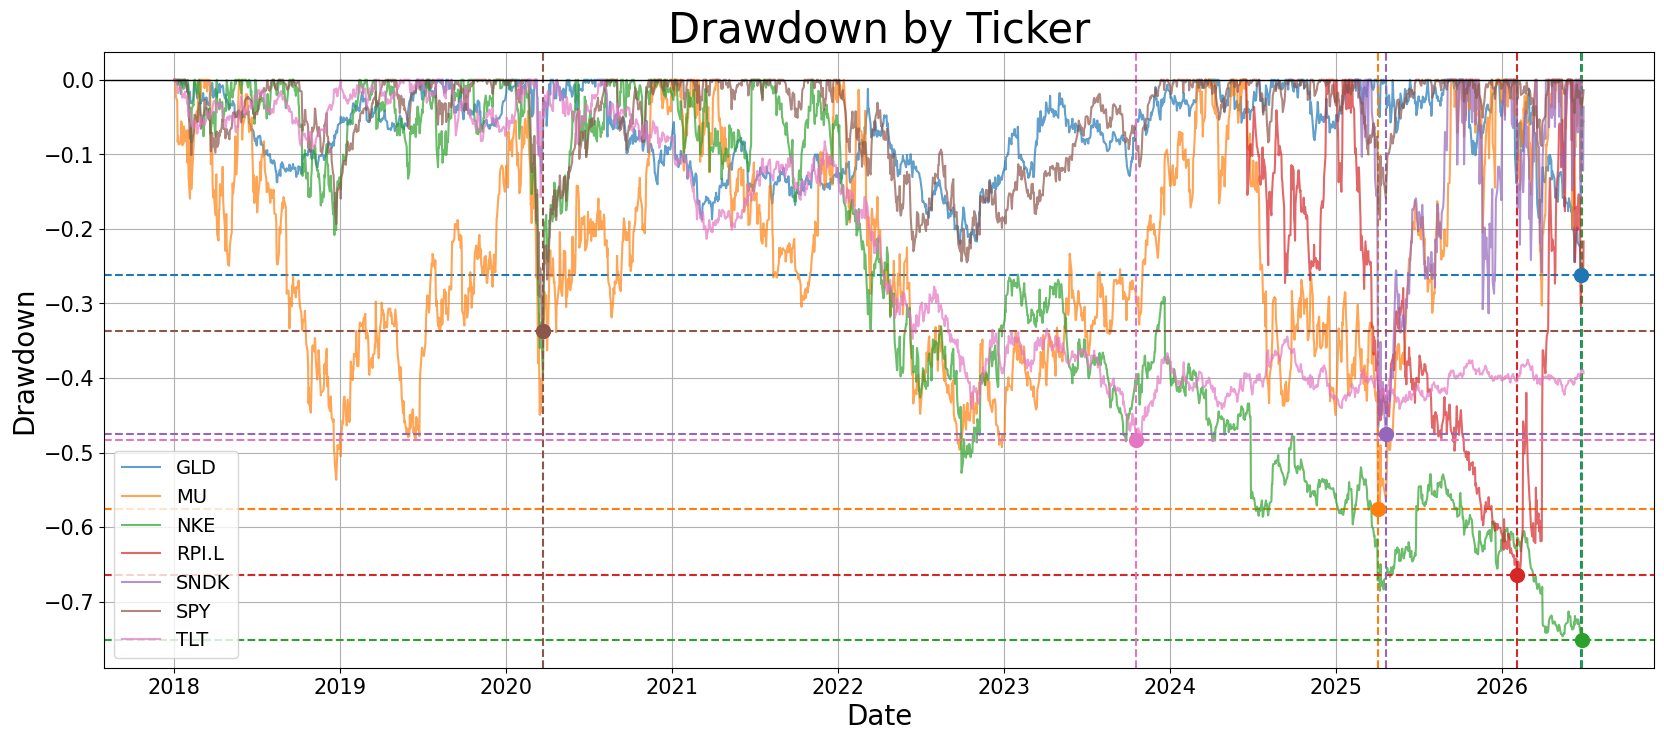

In [32]:
df_2 = df.copy()

drawdown = f"drawdown_{CALENDAR}"
date = "date"
ticker = "ticker"

def recovery_after_drawdown(df):

    trough_idx = df[drawdown].idxmin()
    trough_row = df.loc[trough_idx]

    trough_date = trough_row[date]
    max_drawdown = trough_row[drawdown]

    after_trough = df[df[date] > trough_date]

    recovery = after_trough[after_trough[drawdown] >= -0.000001].head(1)

    if recovery.empty:
        recovery_date = pd.NaT
        recovery_days = pd.NA
    
    else:
        recovery_date = recovery[date].iloc[0]
        recovery_days = (recovery_date - trough_date).days

    return pd.Series({
        "trough_date": trough_date,
        "max_drawdown": max_drawdown,
        "recovery_date": recovery_date,
        "recovery_days": recovery_days
    })

recovery_summary = (
    df_2.groupby(ticker).apply(recovery_after_drawdown)
)

table_count += 1
print(f"Table {table_count}:")

display(recovery_summary)


plt.figure(figsize=(20,8))

for asset, group in df_2.groupby(ticker):

    group = group.sort_values(date)

    line, = plt.plot(group[date], group[drawdown], label=asset, alpha = 0.7)
    colour = line.get_color()

    max_dd_idx = group[drawdown].idxmin()
    max_dd_row = group.loc[max_dd_idx]

    max_dd_date = max_dd_row[date]
    max_dd_value = max_dd_row[drawdown]

    plt.axhline(
        y = max_dd_value,
        color = colour,
        linestyle = "--",
        linewidth = 1.5,
        alpha = 1
    )

    plt.axvline(
        x = max_dd_date,
        color = colour,
        linestyle = "--",
        linewidth = 1.5,
        alpha = 1
    )

    plt.scatter(
        max_dd_date,
        max_dd_value,
        color = colour,
        s = 100,
        zorder = 5
    )

plt.axhline(0, color = "black", linewidth = 1)

plt.title("Drawdown by Ticker", fontsize=30)
plt.xlabel("Date", fontsize=20)
plt.ylabel("Drawdown", fontsize=20)
plt.legend(fontsize=14)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid()

graph_count += 1
print(f"Graph {graph_count}:")

plt.show()


# Drawdown Over Time

In [33]:
import pandas as pd
import numpy as np
from IPython.display import display, display_html

# Your existing columns / variables
drawdown = f"drawdown_{CALENDAR}"

df_3 = df.copy()

df_3[date] = pd.to_datetime(df_3[date])
df_3 = df_3.sort_values([ticker, date])

def make_drawdown_episodes(data, ticker_col, date_col, drawdown_col, tol=1e-6):
    rows = []

    for tkr, g in data.groupby(ticker_col):
        g = g.sort_values(date_col).reset_index(drop=True)

        underwater = g[drawdown_col] < -tol
        i = 0
        episode_no = 0
        last_date = g[date_col].max()

        while i < len(g):

            # Skip rows where asset is not in drawdown
            if not underwater.iloc[i]:
                i += 1
                continue

            # New drawdown episode starts
            episode_no += 1
            start_i = i

            # The peak is usually the row immediately before drawdown starts
            if start_i > 0:
                peak_date = g.loc[start_i - 1, date_col]
            else:
                peak_date = pd.NaT

            # Move forward until drawdown ends
            while i < len(g) and underwater.iloc[i]:
                i += 1

            end_i = i - 1

            # Drawdown segment
            segment = g.iloc[start_i:end_i + 1]

            # Trough = worst drawdown inside the episode
            trough_i = segment[drawdown_col].idxmin()
            trough_date = g.loc[trough_i, date_col]
            max_drawdown = g.loc[trough_i, drawdown_col]

            # Recovery = first row after episode where drawdown is back near zero
            if i < len(g):
                recovery_date = g.loc[i, date_col]
                recovery_days = (recovery_date - trough_date).days
                days_open = pd.NA
                recovered = True
            else:
                recovery_date = pd.NaT
                recovery_days = pd.NA
                days_open = (last_date - trough_date).days
                recovered = False

            rows.append({
                ticker_col: tkr,
                "episode": episode_no,
                "peak_date": peak_date,
                "trough_date": trough_date,
                "max_drawdown": max_drawdown,
                "recovery_date": recovery_date,
                "recovery_days": recovery_days,
                "days_open_if_unrecovered": days_open,
                "recovered": recovered
            })

    return pd.DataFrame(rows)

drawdown_episodes = make_drawdown_episodes(
    data=df_3,
    ticker_col=ticker,
    date_col=date,
    drawdown_col=drawdown
)

drawdown_episodes["trough_year"] = drawdown_episodes["trough_date"].dt.year

drawdown_episodes["recovery_days"] = pd.to_numeric(
    drawdown_episodes["recovery_days"],
    errors="coerce"
)

drawdown_episodes["days_open_if_unrecovered"] = pd.to_numeric(
    drawdown_episodes["days_open_if_unrecovered"],
    errors="coerce"
)

episodes_display = drawdown_episodes.copy()

episodes_display["max_drawdown"] = episodes_display["max_drawdown"].map("{:.2%}".format)

recovery_stats = (
    drawdown_episodes
        .groupby(ticker)
        .agg(
            drawdown_events=("episode", "count"),
            recovered_events=("recovered", "sum"),
            worst_drawdown=("max_drawdown", "min"),
            average_drawdown=("max_drawdown", "mean"),
            median_recovery_days=("recovery_days", "median"),
            average_recovery_days=("recovery_days", "mean"),
            max_recovery_days=("recovery_days", "max"),
            current_open_drawdown_days=("days_open_if_unrecovered", "max")
        )
)

recovery_stats["open_events"] = (
    recovery_stats["drawdown_events"] - recovery_stats["recovered_events"]
)

recovery_stats["recovery_rate"] = (
    recovery_stats["recovered_events"] / recovery_stats["drawdown_events"]
)

recovery_stats = recovery_stats[
    [
        "drawdown_events",
        "recovered_events",
        "open_events",
        "recovery_rate",
        "worst_drawdown",
        "average_drawdown",
        "median_recovery_days",
        "average_recovery_days",
        "max_recovery_days",
        "current_open_drawdown_days"
    ]
]

table_count += 1
print(f"Table {table_count}:")

display(recovery_stats.reset_index().style.hide(axis="index"))


Table 3:


ticker,drawdown_events,recovered_events,open_events,recovery_rate,worst_drawdown,average_drawdown,median_recovery_days,average_recovery_days,max_recovery_days,current_open_drawdown_days
GLD,70,69,1,0.985714,-0.262109,-0.028488,4.000000,20.333333,525.000000,6.000000
MU,65,64,1,0.984615,-0.576290,-0.084536,3.000000,27.656250,700.000000,4.000000
NKE,64,63,1,0.984375,-0.751048,-0.049685,3.000000,10.158730,72.000000,4.000000
RPI.L,12,11,1,0.916667,-0.664230,-0.135425,3.000000,20.000000,111.000000,6.000000
SNDK,31,30,1,0.967742,-0.475009,-0.100572,1.000000,8.366667,135.000000,1.000000
SPY,148,147,1,0.993243,-0.337173,-0.019250,3.000000,11.217687,427.000000,20.000000
TLT,20,19,1,0.950000,-0.483511,-0.054786,5.000000,19.052632,104.000000,985.000000
